# Time Stepping Schemes for PDEs

In the previous notebook, we examined a solution to the 1D heat equation using a forward Euler method. Here, we will investigate other solutions to this equation using the methods introduced in the notebook for ODEs.

**Import the modules for this notebook**

In [12]:
import os
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.patches import Rectangle

## Model Example

As described in the previous notebook, the 1D heat equation describing a temperature in a rod is given by

$$
\frac{\partial T (t,x)}{\partial t} = \kappa \frac{\partial^2 T(t,x)}{\partial x^2}
$$

As in the previous notebook, we'll construct the initial conditions as a gaussian distribution with a peak at the center of the rod.

In [3]:
# define a 10 m grid between -5 and 5
x_min = -5.0 
x_max = 5.0 

# define a spatial step
dx = 0.1

# compute the number of points on the x grid
nx = int((x_max-x_min)/dx) + 1 

# define the x grid
x = np.linspace(x_min, x_max, nx)

# estimate initial conditions
T_0 = 2*np.exp(-(x**2)/0.25) + 10

# starting and ending times (seconds)
t_min = 0.0 
t_max = 100.0

# define kappa
kappa = 0.1 

## Analytical Solution

Since we're going to plottting comparisons several times, let's make a quick plotting function:

In [7]:
def plot_the_temperature_at_different_timesteps(x, dt, T):
    fig = plt.figure(figsize=(8,4))
    
    # plot initial conditions
    plt.plot(x, T[0,:], 'r-', label='0 seconds')
    
    # plot conditions at 2 seconds
    time_index = int(2/dt)
    plt.plot(x, T[time_index,:], '-', color='orange', label='2 seconds')
    
    # plot conditions at 10 seconds
    time_index = int(10/dt)
    plt.plot(x, T[time_index,:], '-', color='yellow', label='10 seconds')
    
    # plot conditions at 20 seconds
    time_index = int(20/dt)
    plt.plot(x, T[time_index,:], '-', color='green', label='20 seconds')
    
    # plot conditions at 10 seconds
    time_index = int(50/dt)
    plt.plot(x, T[time_index,:], '-', color='blue', label='50 seconds')
    
    # plot conditions at 20 seconds
    time_index = int(100/dt)
    plt.plot(x, T[time_index,:], '-', color='purple', label='100 seconds')
    
    # format axes
    plt.legend()
    plt.ylabel('Temperature ($^{\circ}$C)')
    plt.xlabel('Distance along rod (m)')
    plt.grid(linestyle='--',linewidth=0.5)
    plt.show()

## Numerical Solutions

To formulate a numerical solution to the heat equation, we discretize the second-order spatial derivative as 

$$
\frac{\partial^2 T(t,x)}{\partial x^2} \approx \frac{T(t,x+\Delta x) - 2 T(t,x) + T(t,x-\Delta x)}{\Delta x^2}
$$

Then, just as for the ODE examples we looked at, we will formulate the time stepping schemes to determine the next temperature profile in the rod as

$$
T(t+\Delta t,x) = T(t,x) + \Delta t \kappa f(\cdots)
$$

The function $f$ will depend on the spatial discretizartion of temperature in the rod at one or more time steps.

## Euler Methods

### Forward Euler

In the Forward Euler method, we express the temperature of the rod at a time $\Delta t$ in the future as a function of the temperature at the time $t$ and the rate of change at the time $t$:

$$
T(t+\Delta t,x) \approx T(t,x) +\Delta t \frac{\partial T(t,x)}{\partial t}
$$

Using our spatial discretization derived above, we can express our scheme as:

$$
T(t+\Delta t,x)  \approx  T(t,x) +\Delta t \kappa \frac{T(t,x+\Delta x) - 2 T(t,x) + T(t,x-\Delta x)}{\Delta x^2}
$$

We saw this solution in the previous notebook but we can code it up here:

In [8]:
def forward_euler(dt, t_min, t_max, kappa):
    
    # compute number of timesteps
    nt = int((t_max-t_min)/dt) + 1 #number of points on t grid
    
    # make a grid to store the solution
    T = np.zeros((nt, nx))
    
    # establish initial conditions
    T[0, :] = T_0
    
    # loop through each time step up until the last one
    for j in range(nt-1):
        
        # loop through each space step to update the temperature
        # dont include the boundaries
        for i in range(1,len(x)-1): 
            T[j+1,i] = T[j,i] + dt*kappa * (T[j,i-1] - 2*T[j,i] + T[j,i+1] )/(dx**2)
    
        # now, address the boundary conditions
        T[j+1, 0] = T[j+1,1]
        T[j+1, -1] = T[j+1,-2]
    return(T)

Let's check out the solution:

In [9]:
dt = 0.050
T = forward_euler(dt, t_min, t_max, kappa)

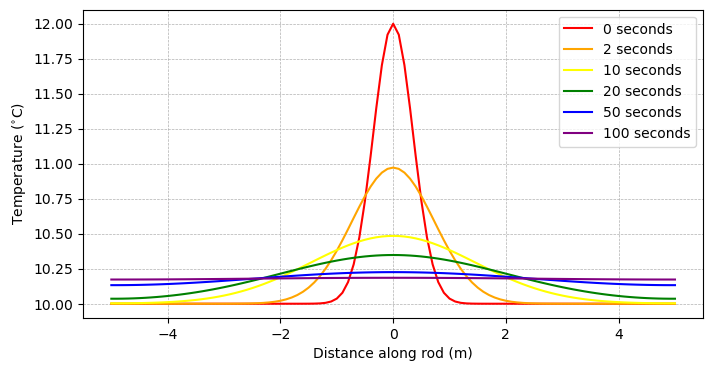

In [10]:
plot_the_temperature_at_different_timesteps(x, dt, T)

Looks good! Not suprising since we already had this solution.

#### Forward Euler CFL Condition

The CFL condition for the Forward Euler condition is:

$$
\Delta t \leq \frac{(\Delta x)^2}{2\kappa}
$$

#### Numerical Stencil for Forward Euler

One way that we can visualize a numerical scheme for a PDE is by assessing it's "stencil" i.e. where in time and space information is being used for a prediction. We can visualize the stencil for the Forward Euler method with the following plotting routing.

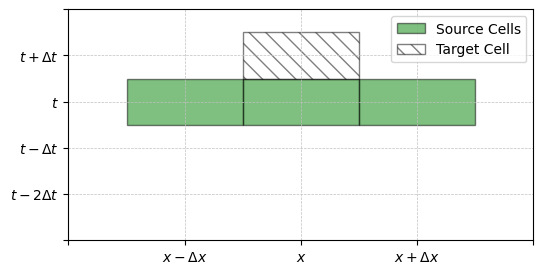

In [44]:
plt.figure(figsize=(6,3))
ax = plt.gca()

# make axis lines
for row in range(1,5):
    plt.plot([0,5],[row,row], '--', color='silver', linewidth=0.5)
for col in range(1,5):
    plt.plot([col,col], [0,5], '--', color='silver', linewidth=0.5)

# patches indicate where in the grid the scheme is operating
ax.add_patch(Rectangle((0.5,2.5),1,1, facecolor='green', edgecolor='k', alpha=0.5))
ax.add_patch(Rectangle((1.5,2.5),1,1, facecolor='green', edgecolor='k', alpha=0.5))
ax.add_patch(Rectangle((2.5,2.5),1,1, facecolor='green', edgecolor='k', alpha=0.5, 
                       label='Source Cells'))
ax.add_patch(Rectangle((1.5,3.5),1,1, facecolor='none', edgecolor='k', alpha=0.5,
                       hatch='\\\\', label='Target Cell'))

# add ticks
plt.xticks(np.arange(5), ['','$x-\Delta x$','$x$','$x+\Delta x$',''])
plt.yticks(np.arange(6), ['','$t-2\Delta t$','$t-\Delta t$','$t$','$t+\Delta t$',''])
plt.xlim([0,4])
plt.ylim([0,5])

# add a legend
plt.legend()

plt.show()

Here, we see that the information at location $x$ and time $t+\Delta t$ is being predicted with information at time $t$ at locations $x-\Delta x$, $x$, and $x+\Delta x$.

### Backward Euler

In the *Backward Euler* method, we express the temperature of the rod at a time $\Delta t$ in the future as a function of the temperature at the time $t$ and the rate of change at the time $t+\Delta t$ i.e. *in the future*. 

$$
T(t+\Delta t,x) \approx T(t,x) +\Delta t \frac{\partial T(t+\Delta t,x)}{\partial t}
$$

Similar to the forward method, we can construct a time stepping scheme as follows: 

$$
T(t+\Delta t,x) \approx  T(t,x) +\Delta t \kappa \frac{T(t+\Delta t,x+\Delta x) - 2 T(t+\Delta t,x) + T(t+\Delta t,x-\Delta x)}{\Delta x^2}
$$

Again, this is an example of an **implicit** scheme, but the solution isn't as straight-forward as for the ODE example earlier. Now, we have THREE bits of information for the future that we need for our solution. 

In [45]:
# Solution here

#### Backward Euler Numerical Stencil

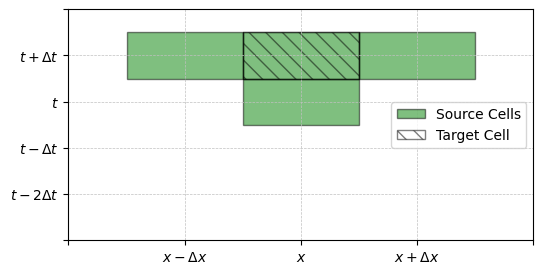

In [47]:
plt.figure(figsize=(6,3))
ax = plt.gca()

# make axis lines
for row in range(1,5):
    plt.plot([0,5],[row,row], '--', color='silver', linewidth=0.5)
for col in range(1,5):
    plt.plot([col,col], [0,5], '--', color='silver', linewidth=0.5)

# patches indicate where in the grid the scheme is operating
ax.add_patch(Rectangle((0.5,3.5),1,1, facecolor='green', edgecolor='k', alpha=0.5))
ax.add_patch(Rectangle((1.5,2.5),1,1, facecolor='green', edgecolor='k', alpha=0.5))
ax.add_patch(Rectangle((1.5,3.5),1,1, facecolor='green', edgecolor='k', alpha=0.5))
ax.add_patch(Rectangle((2.5,3.5),1,1, facecolor='green', edgecolor='k', alpha=0.5, 
                       label='Source Cells'))
ax.add_patch(Rectangle((1.5,3.5),1,1, facecolor='none', edgecolor='k', alpha=0.5,
                       hatch='\\\\', label='Target Cell'))

# add ticks
plt.xticks(np.arange(5), ['','$x-\Delta x$','$x$','$x+\Delta x$',''])
plt.yticks(np.arange(6), ['','$t-2\Delta t$','$t-\Delta t$','$t$','$t+\Delta t$',''])
plt.xlim([0,4])
plt.ylim([0,5])

# add a legend
plt.legend()

plt.show()

In the implicit scheme, the information at location $x$ and time $t+\Delta t$ is being predicted with information at time $t+\Delta t$ at locations $x-\Delta x$, $x$ (itself!!!), and $x+\Delta x$, along with the information at time $t$ and location $x$.

### Crank-Nicolson Scheme

In the Crank-Nicolson scheme, we express the temperature of the rod at a time $\Delta t$ in the future as a function of the temperature at the time $t$ and a combination of the rates of change at the time $t$ *and* the time time $t+\Delta t$. Specifically, the combination is done as an average of the two:


$$
\frac{\partial^2 T}{\partial x^2} \approx \frac{1}{2} \left[ \frac{T(t+\Delta t,x+\Delta x) - 2 T(t+\Delta t,x) + T(t+\Delta t,x-\Delta x)}{\Delta x^2} + \frac{T(t,x+\Delta x) - 2 T(t,x) + T(t,x-\Delta x)}{\Delta x^2}\right]
$$

This method can be thought of as a combination of the explicit and implicit Euler methods.

#### Crank-Nicolson Numerical Stencil

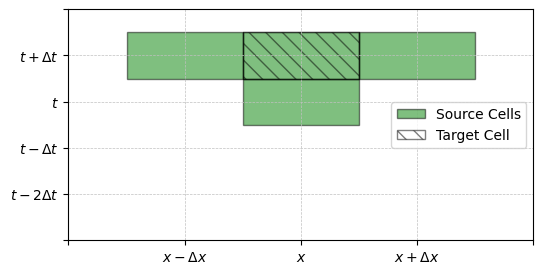

In [48]:
plt.figure(figsize=(6,3))
ax = plt.gca()

# make axis lines
for row in range(1,5):
    plt.plot([0,5],[row,row], '--', color='silver', linewidth=0.5)
for col in range(1,5):
    plt.plot([col,col], [0,5], '--', color='silver', linewidth=0.5)

# patches indicate where in the grid the scheme is operating
ax.add_patch(Rectangle((0.5,3.5),1,1, facecolor='green', edgecolor='k', alpha=0.5))
ax.add_patch(Rectangle((1.5,2.5),1,1, facecolor='green', edgecolor='k', alpha=0.5))
ax.add_patch(Rectangle((1.5,3.5),1,1, facecolor='green', edgecolor='k', alpha=0.5))
ax.add_patch(Rectangle((2.5,3.5),1,1, facecolor='green', edgecolor='k', alpha=0.5, 
                       label='Source Cells'))
ax.add_patch(Rectangle((1.5,3.5),1,1, facecolor='none', edgecolor='k', alpha=0.5,
                       hatch='\\\\', label='Target Cell'))

# add ticks
plt.xticks(np.arange(5), ['','$x-\Delta x$','$x$','$x+\Delta x$',''])
plt.yticks(np.arange(6), ['','$t-2\Delta t$','$t-\Delta t$','$t$','$t+\Delta t$',''])
plt.xlim([0,4])
plt.ylim([0,5])

# add a legend
plt.legend()

plt.show()

## Adams-Bashforth

The Adams-Bashforth method are similar to the scenes above but use two time steps in the past. For example, the Adams-Bashforth 2-step method can be represented as follows:

$$
\frac{\partial^2 T}{\partial x^2} \approx \frac{1}{2} \left[ 3\left(\frac{T(t,x+\Delta x) - 2 T(t,x) + T(t,x-\Delta x)}{\Delta x^2}\right) - \left( \frac{T(t-\Delta t,x+\Delta x) - 2 T(t-\Delta t,x) + T(t-\Delta t,x-\Delta x)}{\Delta x^2}\right)\right]
$$

The method can easily be extended to include additional steps for enhanced numerical stability, but at higher numerical costs.

In [16]:
def adams_bashforth_2(dt, t_min, t_max, kappa):
    
    # compute number of timesteps
    nt = int((t_max-t_min)/dt) + 1 #number of points on t grid
    
    # make a grid to store the solution
    T = np.zeros((nt, nx))
    
    # establish initial conditions
    T[0, :] = T_0
    
    # loop through each time step up until the last one
    for j in range(nt-1):

        if j==0:
            # apply forward euler for the first timestep
            for i in range(1,len(x)-1): 
                T[j+1,i] = T[j,i] + dt*kappa * (T[j,i-1] - 2*T[j,i] + T[j,i+1] )/(dx**2)

        else:
            # apply AB2 for subsequent timesteps
            for i in range(1,len(x)-1): 
                d2T_dx2 = (0.5/(dx**2)) * ( 3*(T[j,i-1] - 2*T[j,i] + T[j,i+1]) - (T[j-1,i-1] - 2*T[j-1,i] + T[j-1,i+1]))
                T[j+1,i] = T[j,i] + dt*kappa *d2T_dx2 
    
        # now, address the boundary conditions
        T[j+1, 0] = T[j+1,1]
        T[j+1, -1] = T[j+1,-2]
        
    return(T)

In [54]:
dt = 0.025
T = adams_bashforth_2(dt, t_min, t_max, kappa)

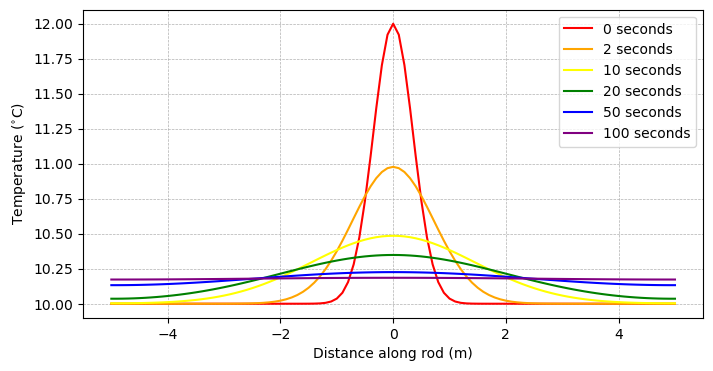

In [55]:
plot_the_temperature_at_different_timesteps(x, dt, T)

#### Adams Bashforth CFL Condition

$$
\Delta t \lesssim \frac{3(\Delta x)^2}{8\kappa}
$$

In [47]:
print('delta_t',dt)
print('CFL',3*dx**2/(8*kappa))

delta_t 0.037
CFL 0.037500000000000006


## Runge-Kutta

$$
f(t+\Delta t,x) =  f(t,x) +\Delta t \kappa \frac{f(t,x+\Delta x) - 2 f(t,x) + f(t,x-\Delta x)}{\Delta x^2}
$$